# TDT-IS: Thailand Domestic Tourism Intelligence System (Phase 2 Report)

## 1. Setup & Config

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.linear_model import LinearRegression
import folium
import json
import time

# 1. Configuration: Path Management
output_dirs = [
    '../web_app/public/data',
    'web_app/public/data',
    '/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/BIA/BIA_Group_Project/TDT-IS_Dashboard/web_app/public/data'
]
output_dir = next((p for p in output_dirs if os.path.exists(p)), output_dirs[-1])
os.makedirs(output_dir, exist_ok=True)
plt.style.use('ggplot')
print(f"Target Output Directory: {output_dir}")

Target Output Directory: ../web_app/public/data


## 2. Data Ingestion

In [2]:
# Data Loading
paths_to_check = [
    '../../archive/thailand_domestic_tourism_2019_2023_ver2.parquet',
    '../data/thailand_domestic_tourism_2019_2023_ver2.parquet',
    './archive/thailand_domestic_tourism_2019_2023_ver2.parquet',
    './data/thailand_domestic_tourism_2019_2023_ver2.parquet',
    '/Users/htutkoko/Library/CloudStorage/GoogleDrive-htutkoko1994@gmail.com/My Drive/AIT/BIA/BIA_Group_Project/archive/thailand_domestic_tourism_2019_2023_ver2.parquet'
]
file_path = next((p for p in paths_to_check if os.path.exists(p)), None)
if file_path is None: raise FileNotFoundError('Dataset not found.')
df = pd.read_parquet(file_path)
df['date'] = pd.to_datetime(df['date'])
df_pivot = df.pivot_table(index=['date', 'province_eng', 'region_eng'], 
                          columns='variable', values='value', aggfunc='sum').reset_index().fillna(0)
print(f"Data shape: {df_pivot.shape}")

Data shape: (3850, 11)


## 3. Exploratory Data Analysis

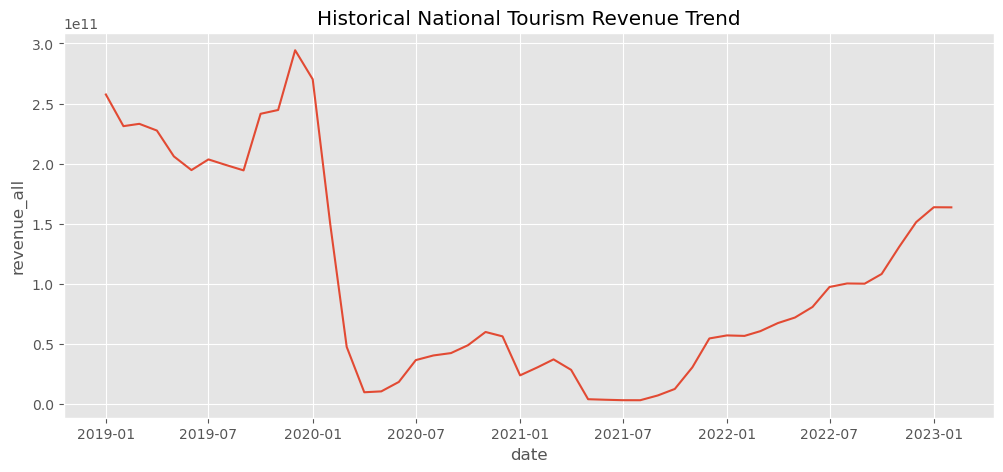

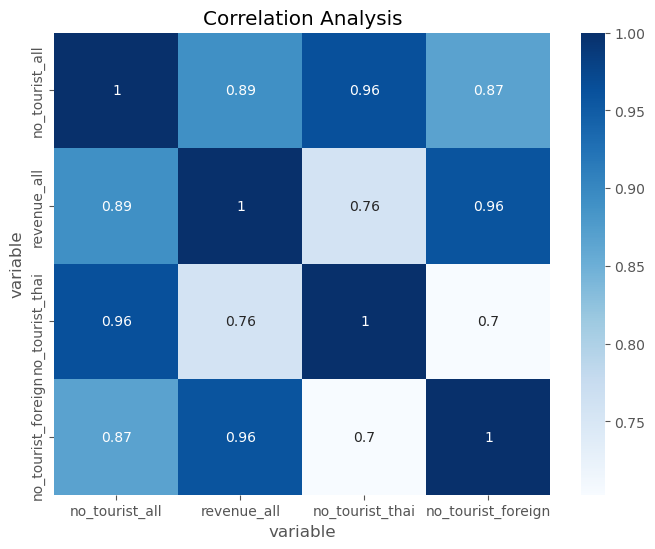

In [3]:
# Exploratory Data Analysis
plt.figure(figsize=(12,5))
sns.lineplot(data=df_pivot.groupby('date')['revenue_all'].sum().reset_index(), x='date', y='revenue_all')
plt.title('Historical National Tourism Revenue Trend')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df_pivot[['no_tourist_all','revenue_all','no_tourist_thai','no_tourist_foreign']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Analysis')
plt.show()

## 4. Time-Series Forecasting (Prophet)

19:12:55 - cmdstanpy - INFO - Chain [1] start processing


19:12:55 - cmdstanpy - INFO - Chain [1] done processing


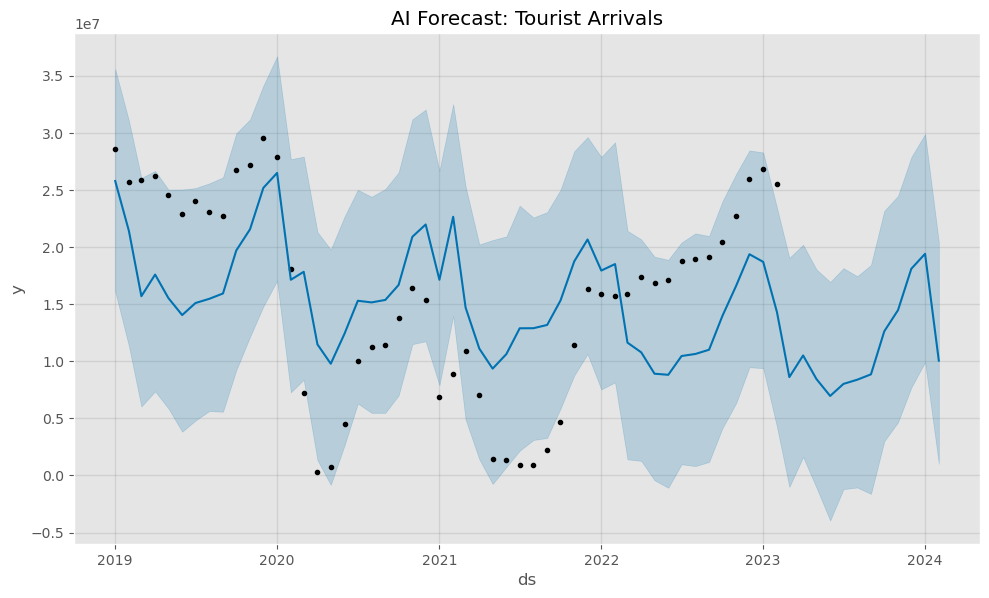

In [4]:
# Time Series Forecasting
national_df = df_pivot.groupby('date')['no_tourist_all'].sum().reset_index()
national_df.columns = ['ds', 'y']
model_nat = Prophet(yearly_seasonality=True)
model_nat.fit(national_df)
future_nat = model_nat.make_future_dataframe(periods=12, freq='MS')
forecast_nat = model_nat.predict(future_nat)

# Plot
model_nat.plot(forecast_nat)
plt.title('AI Forecast: Tourist Arrivals')
plt.show()

## 5. Regression for 'What-If' Simulation

In [5]:
# Regression for What-If Prediction
reg_model = LinearRegression()
X = df_pivot[['no_tourist_all']]
y = df_pivot['revenue_all']
reg_model.fit(X, y)

# Get some real baseline values for UI
last_data_point = df_pivot.groupby('date')['no_tourist_all'].sum().iloc[-1]

model_params = {
    "revenue_per_tourist": float(reg_model.coef_[0]),
    "intercept": float(reg_model.intercept_),
    "baseline_visitors": float(last_data_point)
}

with open(f'{output_dir}/prediction_model.json', 'w') as f_out:
    json.dump(model_params, f_out)
print(f"Regression Model Saved. Baseline Visitors: {last_data_point}")


Regression Model Saved. Baseline Visitors: 25516021.0


## 6. Carrying Capacity (CCI) Analysis

/var/folders/hw/6gvmmc1109n0_c63m731_2nh0000gn/T/ipykernel_19024/2483409904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cci_df[cci_df['Zone']=='Red'].sort_values('CCI', ascending=False).head(10), y='province_eng', x='CCI', palette='Reds_r')


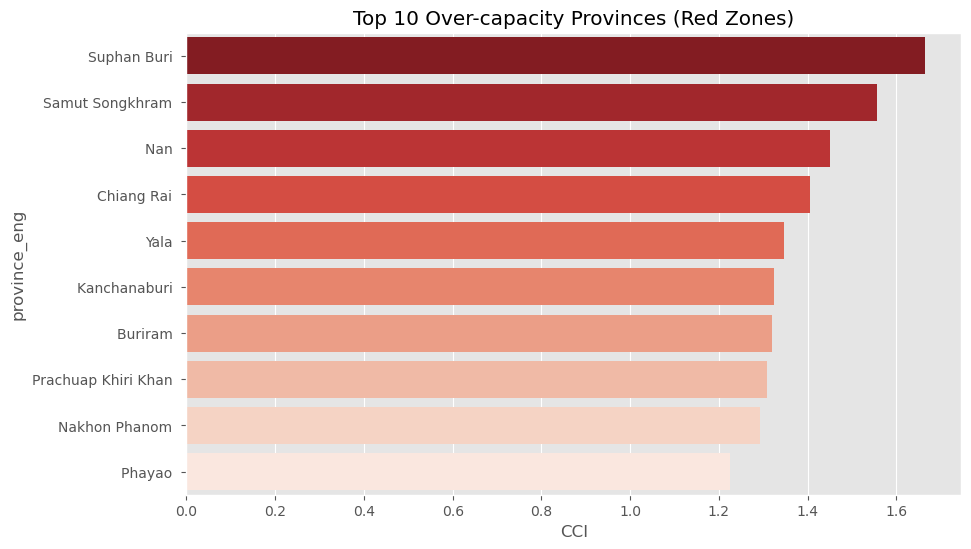

In [6]:
# Carrying Capacity Analysis
recent_df = df_pivot[df_pivot['date'].dt.year == 2023]
avg_visitors = recent_df.groupby(['province_eng', 'region_eng'])['no_tourist_all'].mean().reset_index()
historical_limits = df_pivot.groupby('province_eng')['no_tourist_all'].quantile(0.85).reset_index()
cci_df = pd.merge(avg_visitors, historical_limits, on='province_eng', suffixes=('_curr', '_limit'))
cci_df['CCI'] = cci_df['no_tourist_all_curr'] / cci_df['no_tourist_all_limit'].replace(0,1)
cci_df['Zone'] = cci_df['CCI'].apply(lambda x: 'Red' if x > 1.2 else ('Green' if x < 0.8 else 'Yellow'))

plt.figure(figsize=(10,6))
sns.barplot(data=cci_df[cci_df['Zone']=='Red'].sort_values('CCI', ascending=False).head(10), y='province_eng', x='CCI', palette='Reds_r')
plt.title('Top 10 Over-capacity Provinces (Red Zones)')
plt.show()

## 7. Thailand Geospatial Mapping

In [7]:
# Geospatial Mapping
from geopy.geocoders import Nominatim
m = folium.Map(location=[15.87, 100.9925], zoom_start=6)
geolocator = Nominatim(user_agent="tdt_is_geo")

def add_zones(zone, color):
    subset = cci_df[cci_df['Zone']==zone].sort_values('CCI', ascending=(zone=='Green')).head(5)
    for _, row in subset.iterrows():
        try:
            loc = geolocator.geocode(f"{row['province_eng'].strip()}, Thailand", timeout=5)
            if loc:
                folium.Marker([loc.latitude, loc.longitude], popup=f"{row['province_eng']} (CCI: {row['CCI']:.2f})", icon=folium.Icon(color=color.lower())).add_to(m)
                folium.Circle([loc.latitude, loc.longitude], radius=20000, color=color, fill=True).add_to(m)
        except: pass

add_zones('Red', 'red')
add_zones('Green', 'green')
m.save(f'{output_dir}/thailand_map.html')
display(m)

## 8. Dashboard Export

In [8]:
# Final Data Export
# 1. Forecast
forecast_export_df = forecast_nat[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_export_df['ds'] = forecast_export_df['ds'].dt.strftime('%Y-%m-%d')
history = national_df.copy()
history['ds'] = history['ds'].dt.strftime('%Y-%m-%d')
history['actual'] = history['y']
pd.merge(forecast_export_df, history[['ds', 'actual']], on='ds', how='left').ffill().to_json(f'{output_dir}/national_forecast.json', orient='records')

# 2. CCI
cci_df.to_json(f'{output_dir}/cci_data.json', orient='records')

# 3. Tableau Dashboard Blocks
df_pivot.groupby('province_eng')[['no_tourist_all', 'revenue_all']].sum().sort_values('revenue_all', ascending=False).head(10).reset_index().to_json(f'{output_dir}/top10_provinces.json', orient='records')

demographics = {
    "revenue": [{"name": "Domestic (Thai)", "value": float(df_pivot['revenue_thai'].sum())}, {"name": "Foreign", "value": float(df_pivot['revenue_foreign'].sum())}]
}
with open(f'{output_dir}/demographics.json', 'w') as outf: json.dump(demographics, outf)

df_pivot['year'] = df_pivot['date'].dt.year
df_pivot.groupby('year')[['no_tourist_all', 'revenue_all']].sum().reset_index().to_json(f'{output_dir}/yearly_trend.json', orient='records')

# 4. Regional Summary
df_pivot.groupby('region_eng')[['no_tourist_all', 'revenue_all']].sum().reset_index().to_json(f'{output_dir}/regional_summary.json', orient='records')

print("All Dashboard Assets Exported Successfully.")

All Dashboard Assets Exported Successfully.
